# Лабораторная работа №3: Кластеризация и снижение размерности (DBSCAN, GMM, PCA, Kernel PCA, t-SNE)

**Цель работы:**
С нуля реализовать ключевые алгоритмы кластеризации и снижения размерности, провести исследование влияния гиперпараметров, сравнить с реализациями из scikit-learn и визуализировать результаты.

## Задачи
1. Реализовать DBSCAN (с использованием пространственных индексов или наивного поиска) и исследовать влияние параметров `eps`, `min_samples`.
2. Реализовать EM-алгоритм для Gaussian Mixture Model (GMM) с различными типами ковариационных матриц (`full`, `diag`).
3. Реализовать PCA через спектральное разложение ковариационной матрицы; реализовать Incremental PCA (упрощённо).
4. Реализовать Kernel PCA с RBF-ядром; исследовать параметр `gamma`.
5. Реализовать упрощённый t-SNE: вероятности в высокомерном пространстве, градиентный спуск в низкомерном; исследовать `perplexity` и `learning_rate`.
6. Оценить качество кластеризации (silhouette score, ARI) и качество проекций визуально.
7. Сравнить с `sklearn` реализациями (DBSCAN, GaussianMixture, PCA, KernelPCA, TSNE) на данных Iris, Digits, а также на синтетических кластерах (blobs, moons, circles).
8. Сделать выводы и рекомендации по выбору алгоритмов под разные сценарии.

## Данные
- Iris (классификация, 3 класса)
- Digits (10 классов)
- Синтетика: `make_blobs`, `make_moons`, `make_circles`

## Критерии оценивания (макс 15 баллов)
- Реализация алгоритмов (DBSCAN, GMM, PCA, Kernel PCA, t-SNE) — 7 баллов
- Эксперименты и исследование гиперпараметров (кривые, таблицы, сравнение) — 5 баллов
- Сравнение со scikit-learn и метрики качества (silhouette/ARI) — 2 балла
- Качество отчета и визуализаций — 1 балл

Ограничения на библиотеки реализации: NumPy (основная математика), SciPy (по желанию для расстояний/собственных значений), matplotlib/seaborn (визуализация), scikit-learn — только для загрузки данных, эталонных реализаций и метрик/разбиений.

In [1]:
# Импорты и загрузка данных
import seaborn as sns
from sklearn.datasets import load_iris, load_digits, make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid', context='notebook')

# Загрузка наборов данных
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# Синтетические наборы
X_blobs, y_blobs = make_blobs(n_samples=1000, centers=4, cluster_std=1.0, random_state=42)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.06, random_state=42)
X_circles, y_circles = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

# Масштабирование (важно для расстояний)
scalers = {
    'iris': StandardScaler().fit(X_iris),
    'digits': StandardScaler().fit(X_digits),
    'blobs': StandardScaler().fit(X_blobs),
    'moons': StandardScaler().fit(X_moons),
    'circles': StandardScaler().fit(X_circles),
}
X_iris_s = scalers['iris'].transform(X_iris)
X_digits_s = scalers['digits'].transform(X_digits)
X_blobs_s = scalers['blobs'].transform(X_blobs)
X_moons_s = scalers['moons'].transform(X_moons)
X_circles_s = scalers['circles'].transform(X_circles)

## 1. Реализация DBSCAN
Идея: ядра кластеров определяются плотностью. Точки с достаточным количеством соседей в радиусе `eps` считаются core-точками.

Задачи:
- Реализовать поиск соседей в радиусе (наивно O(n^2) достаточно; опционально KD-дерево)
- Пометить core/border/noise
- Распространить метку кластера при обходе соседей

Функции, которые нужно реализовать:
- `region_query(X, i, eps)`
- `fit_dbscan(X, eps, min_samples)` возвращает `labels`

Число кластеров (без шума): 2


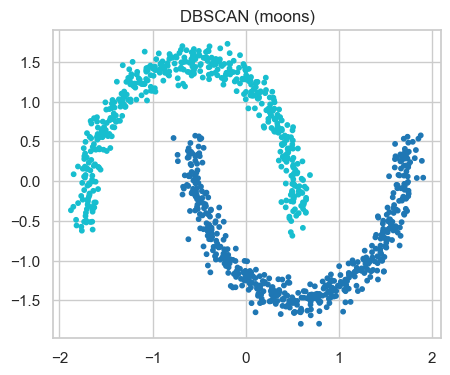

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

def pairwise_sq_dists(X):
    """
    Векторизованное вычисление попарных квадратов евклидовых расстояний.
    Возвращает матрицу shape (n, n), где [i, j] = ||x_i - x_j||^2
    """
    X = np.asarray(X)
    norms = np.sum(X**2, axis=1, keepdims=True)
    sq_dists = norms + norms.T - 2 * X @ X.T
    sq_dists = np.clip(sq_dists, 0, None)
    return sq_dists


def region_query(X, i, eps, sq_dists=None):
    """
    Возвращает список индексов точек в eps-окрестности точки i (включая i).
    Оптимизация: при наличии sq_dists — используем её, иначе вычисляем на лету.
    """
    if sq_dists is not None:
        return np.where(sq_dists[i] <= eps**2)[0]
    else:
        diffs = X - X[i]
        dists_sq = np.sum(diffs**2, axis=1)
        return np.where(dists_sq <= eps**2)[0]


def fit_dbscan(X, eps=0.5, min_samples=5):
    """
    Реализация DBSCAN.
    Возвращает массив меток: -1 — шум, 0,1,2,... — кластеры.
    """
    X = np.asarray(X)
    n = X.shape[0]
    labels = np.full(n, -2)

    sq_dists = pairwise_sq_dists(X)

    cluster_id = 0

    for i in range(n):
        if labels[i] != -2:
            continue

        neighbors = region_query(X, i, eps, sq_dists)

        if len(neighbors) < min_samples:
            labels[i] = -1
            continue

        labels[i] = cluster_id
        queue = deque(neighbors)

        while queue:
            j = queue.popleft()

            if labels[j] == -1:
                labels[j] = cluster_id
            elif labels[j] == -2:
                labels[j] = cluster_id

                j_neighbors = region_query(X, j, eps, sq_dists)
                if len(j_neighbors) >= min_samples:
                    for k in j_neighbors:
                        if labels[k] == -2 or labels[k] == -1:
                            queue.append(k)

        cluster_id += 1

    return labels


# Пример запуска на 'moons'
labels_moons = fit_dbscan(X_moons_s, eps=0.3, min_samples=5)
print('Число кластеров (без шума):', len(set(labels_moons)) - (1 if -1 in labels_moons else 0))
plt.figure(figsize=(5, 4))
plt.scatter(X_moons_s[:, 0], X_moons_s[:, 1], c=labels_moons, cmap='tab10', s=10)
plt.title('DBSCAN (moons)')
plt.show()

Эксперименты с DBSCAN:
   - Постройте графики количества кластеров и доли шума в зависимости от `eps` и `min_samples`.
   - Сравните с `sklearn.cluster.DBSCAN` по метрикам ARI (если есть истинные метки) и silhouette score (по предсказанным меткам, исключая шум).
   - Отдельно покажите результаты на `moons` и `circles` (криволинейные кластеры).

Выполняется подбор параметров DBSCAN...


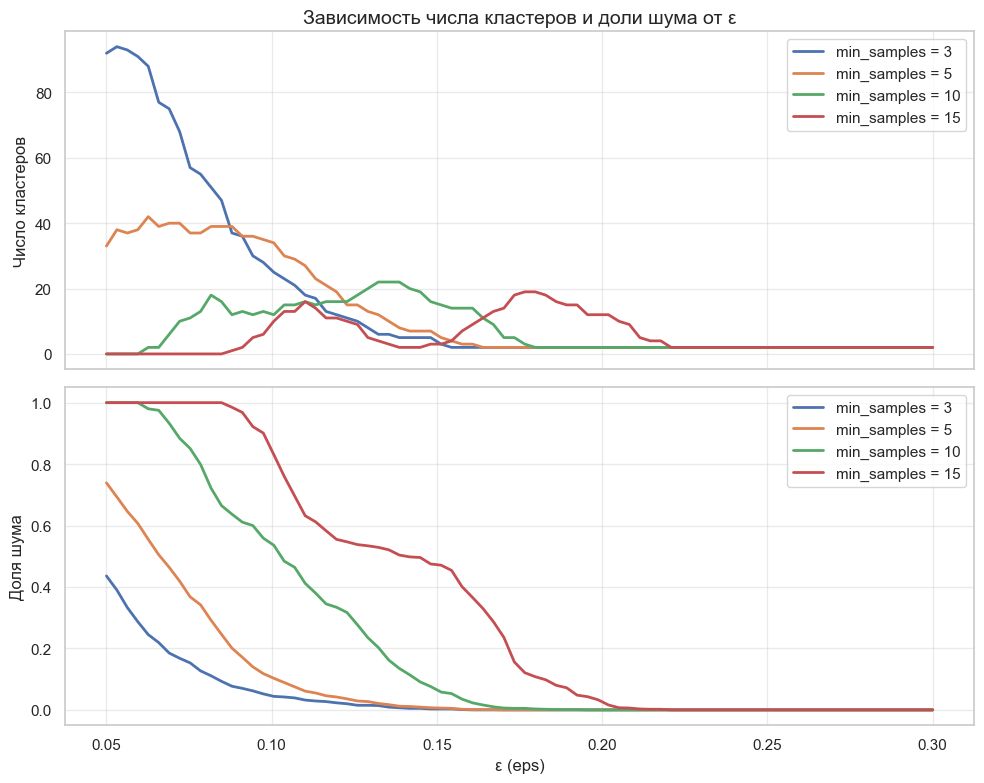

In [3]:
X = X_circles_s

eps_values = np.linspace(0.05, 0.3, 80)
min_samples_list = [3, 5, 10, 15]

n_clusters_dict = {ms: [] for ms in min_samples_list}
noise_ratio_dict = {ms: [] for ms in min_samples_list}

print("Выполняется подбор параметров DBSCAN...")
for min_samples in min_samples_list:
    for eps in eps_values:
        labels = fit_dbscan(X, eps=eps, min_samples=min_samples)

        unique_labels = np.unique(labels)
        n_noise = np.sum(labels == -1)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        
        n_clusters_dict[min_samples].append(n_clusters)
        noise_ratio_dict[min_samples].append(n_noise / len(labels))

# Построение
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ms in min_samples_list:
    ax1.plot(eps_values, n_clusters_dict[ms], label=f'min_samples = {ms}', linewidth=2)
ax1.set_ylabel('Число кластеров')
ax1.set_title('Зависимость числа кластеров и доли шума от ε', fontsize=14)
ax1.grid(True, alpha=0.4)
ax1.legend()

for ms in min_samples_list:
    ax2.plot(eps_values, noise_ratio_dict[ms], label=f'min_samples = {ms}', linewidth=2)
ax2.set_xlabel('ε (eps)')
ax2.set_ylabel('Доля шума')
ax2.grid(True, alpha=0.4)
ax2.legend()
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

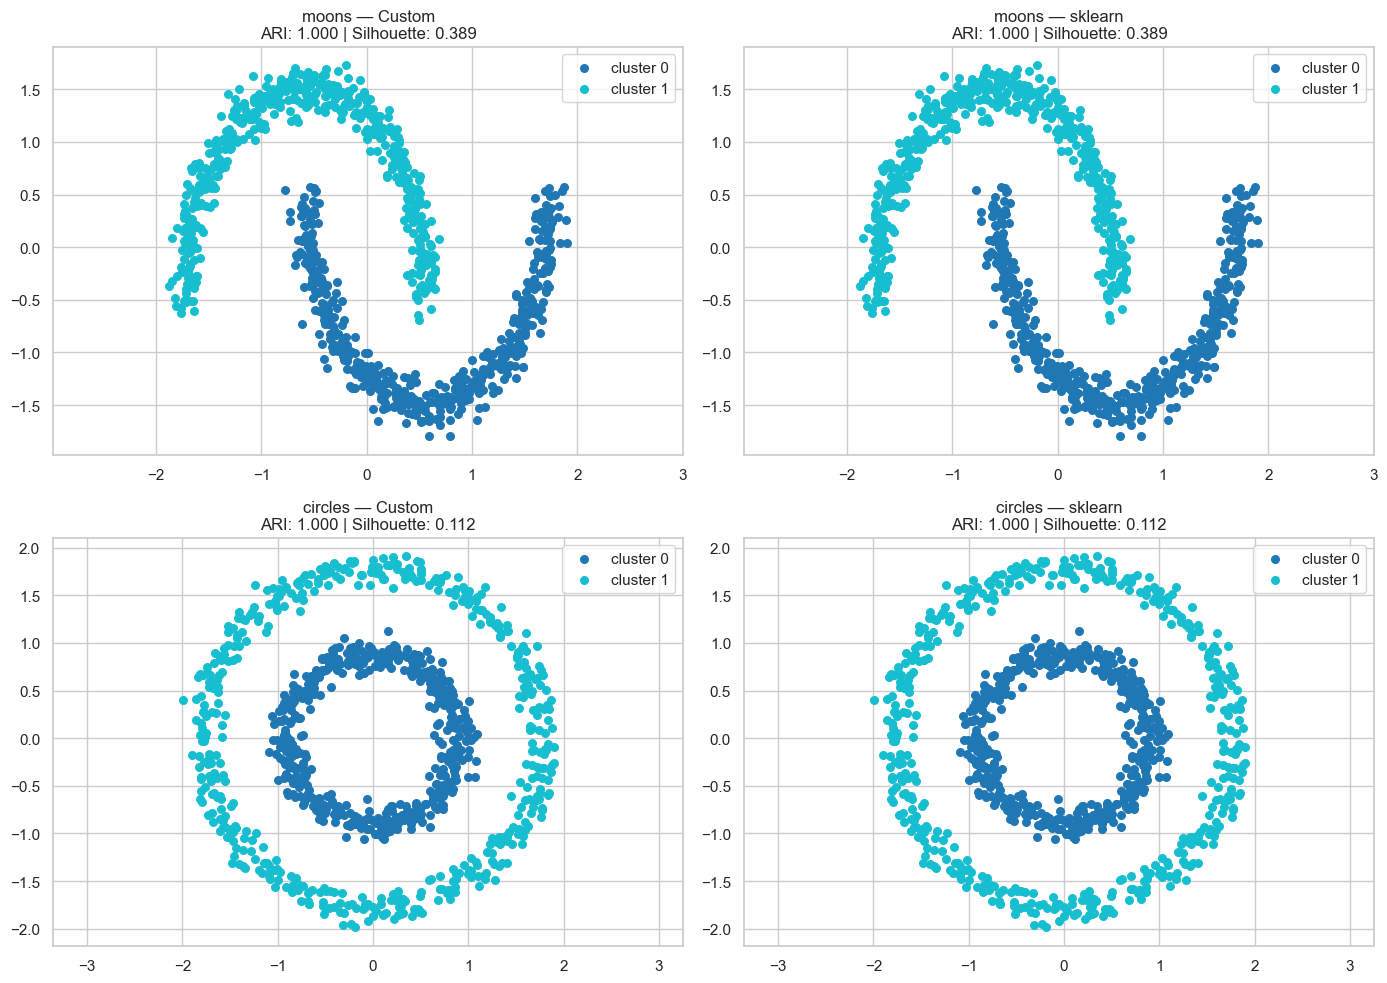

Сравнение метрик (ARI и Silhouette, без шума):
-------------------------------------------------------
Dataset    | Метод      |      ARI | Silhouette
-------------------------------------------------------
moons      | custom     |    1.000 |      0.389
moons      | sklearn    |    1.000 |      0.389
circles    | custom     |    1.000 |      0.112
circles    | sklearn    |    1.000 |      0.112
-------------------------------------------------------


In [4]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Функция для вычисления silhouette_score без учёта шума
def silhouette_score_no_noise(X, labels):
    mask = labels != -1
    if np.sum(mask) < 2:
        return np.nan
    return silhouette_score(X[mask], labels[mask])

# Настройки DBSCAN для moons и circles (подбираем эмпирически)
params = {
    'moons':   {'eps': 0.2, 'min_samples': 5},
    'circles': {'eps': 0.2, 'min_samples': 5},
}

datasets = {
    'moons':   (X_moons_s, y_moons),
    'circles': (X_circles_s, y_circles),
}

results = {}

plt.figure(figsize=(14, 10))
plot_idx = 1

for name, (X, y_true) in datasets.items():
    eps = params[name]['eps']
    min_samples = params[name]['min_samples']

    # Моя реализация
    labels_custom = fit_dbscan(X, eps=eps, min_samples=min_samples)

    # sklearn DBSCAN
    dbscan_sk = DBSCAN(eps=eps, min_samples=min_samples)
    labels_sk = dbscan_sk.fit_predict(X)

    # ARI и silhouette (без шума)
    ari_custom = adjusted_rand_score(y_true, labels_custom)
    sil_custom = silhouette_score_no_noise(X, labels_custom)

    ari_sk = adjusted_rand_score(y_true, labels_sk)
    sil_sk = silhouette_score_no_noise(X, labels_sk)

    results[name] = {
        'custom': {'ARI': ari_custom, 'Silhouette': sil_custom},
        'sklearn': {'ARI': ari_sk, 'Silhouette': sil_sk},
    }

    # Визуализация
    for method, labels, col in [('Custom', labels_custom, 'tab:blue'), ('sklearn', labels_sk, 'tab:orange')]:
        plt.subplot(2, 2, plot_idx)
        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
        color_map = {label: colors[i] if label != -1 else 'lightgray' for i, label in enumerate(unique_labels)}

        for label in unique_labels:
            mask = labels == label
            if label == -1:
                plt.scatter(X[mask, 0], X[mask, 1], c='lightgray', s=20, alpha=0.6, label='noise')
            else:
                plt.scatter(X[mask, 0], X[mask, 1], c=[color_map[label]], s=30, label=f'cluster {label}')
        plt.title(f'{name} — {method}\nARI: {adjusted_rand_score(y_true, labels):.3f} | Silhouette: {silhouette_score_no_noise(X, labels):.3f}')
        plt.legend()
        plt.axis('equal')
        plot_idx += 1

plt.tight_layout()
plt.show()

# Вывод таблицы сравнения
print("Сравнение метрик (ARI и Silhouette, без шума):")
print("-" * 55)
print(f"{'Dataset':<10} | {'Метод':<10} | {'ARI':>8} | {'Silhouette':>10}")
print("-" * 55)
for name in datasets:
    for method in ['custom', 'sklearn']:
        ari = results[name][method]['ARI']
        sil = results[name][method]['Silhouette']
        print(f"{name:<10} | {method:<10} | {ari:>8.3f} | {sil:>10.3f}")
print("-" * 55)

## 2. Реализация GMM (EM-алгоритм)
Шаги EM:
   - E-шаг: оценка responsibilities $\gamma_{ik} = p(z_k=1|x_i)$
   - M-шаг: обновление $\pi_k, \mu_k, \Sigma_k$
    
Реализовать класс `MyGMM` с поддержкой `full` и `diag` ковариаций, выбором числа компонент K, критериями остановки и лог-правдоподобием по итерациям. Сравнить с `sklearn.mixture.GaussianMixture`.
    
Метрики: ARI при наличии истинных меток (Iris, Digits), лог-правдоподобие, AIC/BIC (особенно для выбора K).

Эксперименты с GMM:
- Сравнить `full` vs `diag` ковариации (скорость/качество).
- Перебор числа компонент K и сравнение по AIC/BIC (для `sklearn` модели показать графики).

In [5]:
from scipy.linalg import cholesky, solve_triangular

def log_gaussian(X, mu, Sigma, cov_type='full'):
    """
    Вычисляет логарифм плотности вероятности нормального распределения для каждого объекта в X.

    Параметры:
        X — массив признаков, размер (n_samples, n_features)
        mu — вектор средних, размер (n_features,)
        Sigma — ковариационная матрица:
               - при cov_type='diag': вектор дисперсий, размер (n_features,)
               - при cov_type='full': матрица, размер (n_features, n_features)
        cov_type — тип ковариации: 'full' (полная) или 'diag' (диагональная)

    Возвращает:
        log_probs — логарифмы плотностей, размер (n_samples,)
    """
    n, d = X.shape
    if cov_type == 'diag':
        inv_Sigma = 1.0 / Sigma
        diff = X - mu
        quad = -0.5 * np.sum(diff**2 * inv_Sigma, axis=1)
        log_det = np.sum(np.log(Sigma))
        const = -0.5 * (d * np.log(2 * np.pi) + log_det)
        return quad + const

    elif cov_type == 'full':
        # Разложение Холецкого для численной устойчивости
        try:
            L = cholesky(Sigma, lower=True)
        except np.linalg.LinAlgError:
            jitter = 1e-6 * np.eye(d)
            L = cholesky(Sigma + jitter, lower=True)
        diff = X - mu
        y = solve_triangular(L, diff.T, lower=True)
        mahal = np.sum(y**2, axis=0)
        log_det = 2.0 * np.sum(np.log(np.diag(L)))
        const = -0.5 * (d * np.log(2 * np.pi) + log_det)
        return -0.5 * mahal + const

    else:
        raise ValueError("Параметр cov_type должен быть 'full' или 'diag'")

class MyGMM:
    def __init__(self, n_components=1, cov_type='full', tol=1e-6, max_iter=200, reg_covar=1e-6, random_state=None):
        """
        Конструктор GMM модели.

        Параметры:
            n_components — число гауссиан (компонент смеси)
            cov_type — тип ковариационной матрицы: 'full' или 'diag'
            tol — порог для остановки по изменению лог-правдоподобия
            max_iter — максимальное число итераций EM-алгоритма
            reg_covar — небольшое положительное число, добавляемое к диагонали ковариаций для устойчивости
            random_state — зерно генератора случайных чисел для воспроизводимости
        """
        self.n_components = n_components
        self.cov_type = cov_type
        self.tol = tol
        self.max_iter = max_iter
        self.reg_covar = reg_covar
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)

    def _init_params(self, X):
        """
        Инициализация параметров модели: весов, центров и ковариаций.
        """
        n, d = X.shape
        K = self.n_components

        # Случайная инициализация центров (средних) из данных
        idx = np.random.choice(n, K, replace=False)
        self.means_ = X[idx].copy()

        # Равномерная инициализация весов компонент
        self.weights_ = np.full(K, 1.0 / K)

        # Инициализация ковариационных матриц
        if self.cov_type == 'diag':
            # Диагональный случай: дисперсии по признакам + регуляризация
            var_global = np.var(X, axis=0) + self.reg_covar
            self.covs_ = np.tile(var_global, (K, 1))  # (K, d)
        elif self.cov_type == 'full':
            # Полный случай: общая ковариационная матрица + регуляризация
            cov_global = np.cov(X, rowvar=False) + self.reg_covar * np.eye(d)
            self.covs_ = np.tile(cov_global, (K, 1, 1))  # (K, d, d)
        else:
            raise ValueError("Параметр cov_type должен быть 'full' или 'diag'")

    def fit(self, X):
        """
        Обучение модели методом EM.

        Параметры:
            X — обучающая выборка, массив размера (n_samples, n_features)

        Возвращает:
            self — обученную модель
        """
        X = np.asarray(X)
        n, d = X.shape
        K = self.n_components
        self.log_likelihood_curve_ = []

        # Инициализация параметров
        self._init_params(X)

        # Начальное значение лог-правдоподобия
        log_likelihood_prev = -np.inf

        # Основной цикл EM-алгоритма
        for it in range(self.max_iter):

            # E-шаг
            log_resp = np.empty((n, K))
            for k in range(K):
                # Логарифм совместной вероятности: лог веса + лог плотности нормального распределения
                log_resp[:, k] = np.log(self.weights_[k] + 1e-300) + log_gaussian(
                    X, self.means_[k], self.covs_[k], self.cov_type
                )
            # Нормализация в лог-пространстве для устойчивости
            log_sum_exp = np.logaddexp.reduce(log_resp, axis=1, keepdims=True)
            log_resp -= log_sum_exp
            resp = np.exp(log_resp)

            # Вычисление среднего лог-правдоподобия
            log_likelihood = np.mean(log_sum_exp.ravel())
            self.log_likelihood_curve_.append(log_likelihood)

            # Проверка условия остановки
            if np.abs(log_likelihood - log_likelihood_prev) < self.tol:
                break
            log_likelihood_prev = log_likelihood

            # M-шаг
            Nk = np.sum(resp, axis=0) + 1e-300

            # Обновление весов компонент
            self.weights_ = Nk / n

            # Обновление центров (средних)
            self.means_ = (resp.T @ X) / Nk[:, None]

            # Обновление ковариационных матриц
            if self.cov_type == 'diag':
                diff = X[:, None, :] - self.means_[None, :, :]
                weighted_sq = resp[:, :, None] * (diff ** 2)
                cov_k = np.sum(weighted_sq, axis=0) / Nk[:, None]
                self.covs_ = cov_k + self.reg_covar

            elif self.cov_type == 'full':
                for k in range(K):
                    diff_k = X - self.means_[k]
                    weighted_outer = resp[:, k][:, None, None] * (diff_k[:, :, None] @ diff_k[:, None, :])
                    Sigma_k = np.sum(weighted_outer, axis=0) / Nk[k]
                    self.covs_[k] = Sigma_k + self.reg_covar * np.eye(d)

        self.converged_ = (it < self.max_iter - 1)
        self.n_iter_ = it + 1
        return self

    def predict_proba(self, X):
        """
        Возвращает вероятности принадлежности каждого объекта к каждой компоненте.

        Параметры:
            X — данные, размер (n_samples, n_features)

        Возвращает:
            responsibilities — матрица ответственностей, размер (n_samples, n_components)
        """
        X = np.asarray(X)
        n, d = X.shape
        K = self.n_components
        log_resp = np.empty((n, K))
        for k in range(K):
            log_resp[:, k] = np.log(self.weights_[k] + 1e-300) + log_gaussian(
                X, self.means_[k], self.covs_[k], self.cov_type
            )
        # Нормализация в лог-пространстве
        log_sum_exp = np.logaddexp.reduce(log_resp, axis=1, keepdims=True)
        log_resp -= log_sum_exp
        return np.exp(log_resp)

    def predict(self, X):
        """
        Возвращает метки кластеров (номер наиболее вероятной компоненты).

        Параметры:
            X — данные, размер (n_samples, n_features)

        Возвращает:
            labels — вектор меток, размер (n_samples,)
        """
        return np.argmax(self.predict_proba(X), axis=1)

MyGMM ARI (Iris): 0.9039
sklearn GMM ARI (Iris): 0.9039


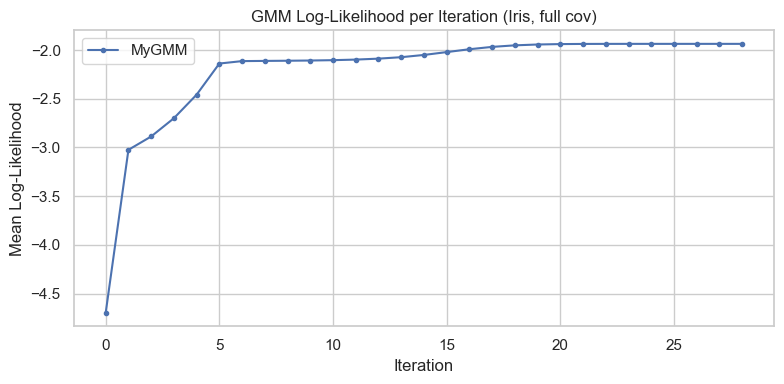

In [6]:
from sklearn.mixture import GaussianMixture as SKGMM

# MyGMM
gmm = MyGMM(n_components=3, cov_type='full', tol=1e-6, max_iter=200, random_state=42)
gmm.fit(X_iris_s)
labels_gmm = gmm.predict(X_iris_s)
ari_gmm = adjusted_rand_score(y_iris, labels_gmm)
print('MyGMM ARI (Iris):', round(ari_gmm, 4))

# sklearn GMM
sk_gmm = SKGMM(
    n_components=3,
    covariance_type='full',
    random_state=42,
    tol=1e-6,
    max_iter=200,
    n_init=10
)
sk_gmm.fit(X_iris_s)
labels_skgmm = sk_gmm.predict(X_iris_s)
ari_skgmm = adjusted_rand_score(y_iris, labels_skgmm)
print('sklearn GMM ARI (Iris):', round(ari_skgmm, 4))

# Кривая лог-правдоподобия
plt.figure(figsize=(8, 4))
plt.plot(gmm.log_likelihood_curve_, label='MyGMM', marker='o', markersize=3)
plt.title('GMM Log-Likelihood per Iteration (Iris, full cov)')
plt.xlabel('Iteration')
plt.ylabel('Mean Log-Likelihood')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Реализация PCA и Incremental PCA

Задачи:
- Центрировать данные, разобрать ковариационную матрицу, получить собственные векторы/значения, отсортировать по убыванию.
- Проекция в k-мерное подпространство.
- Визуализация доли объяснённой дисперсии по k.
- Реализовать простую версию Incremental PCA: обрабатывать данные батчами (например, обновлять ковариацию или SVD на батче с последующим объединением — допустим упрощённый подход с усреднением ковариаций между батчами).

Упрощённый Incremental PCA (идея: аккумулировать сумму и сумму квадратов для обновления оценки ковариации между батчами; для строгого соответствия `SKIPCA` достаточно продемонстрировать аппроксимацию и сравнить визуально/по ошибке реконструкции).

In [7]:
class MyPCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.singular_values_ = None

    def fit(self, X):
        # Центрирование
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # Ковариационная матрица
        n_samples = X.shape[0]
        cov = np.dot(X_centered.T, X_centered) / (n_samples - 1)

        # Собственные значения и векторы
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Сортировка по убыванию (по собственным значениям)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Выбор компонент
        if self.n_components is None:
            self.n_components = X.shape[1]
        self.n_components = min(self.n_components, X.shape[1])

        self.explained_variance_ = eigenvalues[:self.n_components]
        total_var = eigenvalues.sum()
        self.explained_variance_ratio_ = self.explained_variance_ / total_var
        self.singular_values_ = np.sqrt((n_samples - 1) * self.explained_variance_)
        self.components_ = eigenvectors[:, :self.n_components].T

        return self

    def transform(self, X):
        if self.mean_ is None or self.components_ is None:
            raise ValueError("Метод fit не вызван.")
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_.T)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        return np.dot(Z, self.components_) + self.mean_

In [8]:
class MyIncrementalPCA(MyPCA):
    def __init__(self, n_components=None, batch_size=None):
        super().__init__(n_components=n_components)
        self.batch_size = batch_size
        # Состояние для инкрементального обновления
        self.n_samples_seen_ = 0
        self.mean_ = None
        self._sum_cov = None
    
    def partial_fit(self, X):
        """
        Обновляет модель по новому батчу X.
        """
        n_batch, n_features = X.shape

        if self.n_samples_seen_ == 0:
            self.mean_ = np.mean(X, axis=0).astype(np.float64)
            X_centered = X - self.mean_
            self._sum_cov = X_centered.T @ X_centered
            self.n_samples_seen_ = n_batch
        else:
            sum_X_batch = X.sum(axis=0)
            new_total = self.n_samples_seen_ + n_batch
            delta = (sum_X_batch / n_batch - self.mean_)
            self.mean_ += delta * n_batch / new_total
            X_centered = X - self.mean_
            batch_cov_sum = X_centered.T @ X_centered
            self._sum_cov += batch_cov_sum
            self.n_samples_seen_ = new_total

        return self

    def fit(self, X):
        """
        Полная подгонка (не инкрементальная), для совместимости.
        Можно вызывать, но лучше использовать partial_fit батчами.
        """
        if self.batch_size is None:
            # Стандартный fit через родителя
            return super().fit(X)
        else:
            self.n_samples_seen_ = 0
            self.mean_ = None
            self._sum_cov = None

            n_samples = X.shape[0]
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                self.partial_fit(X[start:end])
            self._finalize()
            return self

    def _finalize(self):
        """Вычисляет компоненты по накопленной ковариации."""
        if self.n_samples_seen_ < 2:
            raise ValueError("Недостаточно данных для оценки ковариации.")
        # Ковариация: cov = sum_cov / (n - 1)
        cov = self._sum_cov / (self.n_samples_seen_ - 1)

        # Собственные значения и векторы
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        n_features = cov.shape[0]
        if self.n_components is None:
            self.n_components = n_features
        self.n_components = min(self.n_components, n_features)

        self.explained_variance_ = eigenvalues[:self.n_components]
        total_var = eigenvalues.sum()
        self.explained_variance_ratio_ = self.explained_variance_ / total_var
        self.singular_values_ = np.sqrt((self.n_samples_seen_ - 1) * self.explained_variance_)
        self.components_ = eigenvectors[:, :self.n_components].T

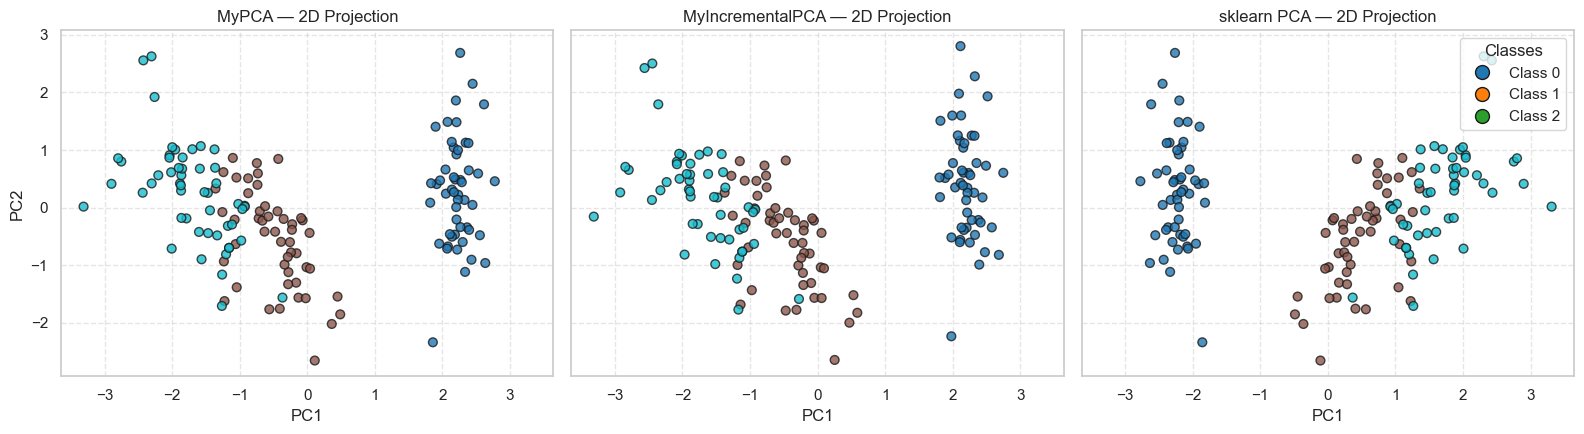

In [9]:
from sklearn.decomposition import PCA as SKPCA

# MyPCA (2 компоненты)
my_pca_2d = MyPCA(n_components=2).fit(X_iris_s)
Z_my = my_pca_2d.transform(X_iris_s)

# sklearn PCA (2 компоненты)
sk_pca_2d = SKPCA(n_components=2, random_state=42).fit(X_iris_s)
Z_sk = sk_pca_2d.transform(X_iris_s)

# MyIncrementalPCA (2 компоненты)
inc_pca_2d = MyIncrementalPCA(n_components=2, batch_size=25).fit(X_iris_s)
Z_inc = inc_pca_2d.transform(X_iris_s)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

# MyPCA
scatter1 = axes[0].scatter(Z_my[:, 0], Z_my[:, 1], c=y_iris, cmap='tab10', s=40, edgecolor='k', alpha=0.8)
axes[0].set_title('MyPCA — 2D Projection')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, linestyle='--', alpha=0.5)

# MyIncrementalPCA
scatter2 = axes[1].scatter(Z_inc[:, 0], Z_inc[:, 1], c=y_iris, cmap='tab10', s=40, edgecolor='k', alpha=0.8)
axes[1].set_title('MyIncrementalPCA — 2D Projection')
axes[1].set_xlabel('PC1')
axes[1].grid(True, linestyle='--', alpha=0.5)

# sklearn PCA
scatter3 = axes[2].scatter(Z_sk[:, 0], Z_sk[:, 1], c=y_iris, cmap='tab10', s=40, edgecolor='k', alpha=0.8)
axes[2].set_title('sklearn PCA — 2D Projection')
axes[2].set_xlabel('PC1')
axes[2].grid(True, linestyle='--', alpha=0.5)

# Легенда
classes = np.unique(y_iris)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab10(i), 
                      markersize=10, markeredgecolor='k') for i in range(len(classes))]
axes[2].legend(handles, [f'Class {i}' for i in classes], title='Classes', loc='upper right')

plt.tight_layout()
plt.show()

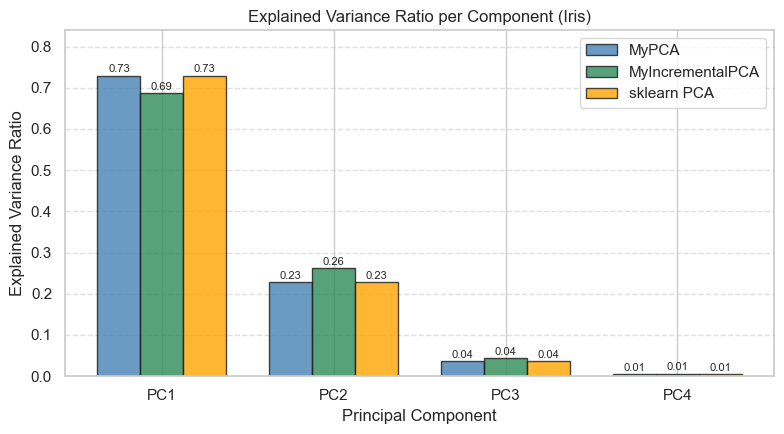

In [10]:
# Полные модели для сравнения объяснённой дисперсии
my_pca_full = MyPCA(n_components=X_iris_s.shape[1]).fit(X_iris_s)
sk_pca_full = SKPCA(n_components=X_iris_s.shape[1], random_state=42).fit(X_iris_s)
inc_pca_full = MyIncrementalPCA(n_components=X_iris_s.shape[1], batch_size=25).fit(X_iris_s)

n_comp = len(my_pca_full.explained_variance_ratio_)
x = np.arange(1, n_comp + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))

width = 0.25
x = np.arange(1, n_comp + 1)  # n_comp = 4

bars1 = ax.bar(x - width, my_pca_full.explained_variance_ratio_, width,
               label='MyPCA', color='steelblue', alpha=0.8, edgecolor='k')
bars2 = ax.bar(x, inc_pca_full.explained_variance_ratio_, width,
               label='MyIncrementalPCA', color='seagreen', alpha=0.8, edgecolor='k')
bars3 = ax.bar(x + width, sk_pca_full.explained_variance_ratio_, width,
               label='sklearn PCA', color='orange', alpha=0.8, edgecolor='k')

for bars, label in zip([bars1, bars2, bars3], ['MyPCA', 'MyIncPCA', 'skPCA']):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio per Component (Iris)')
ax.set_xticks(x)
ax.set_xticklabels([f'PC{i}' for i in x])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_ylim(0, max(np.max(my_pca_full.explained_variance_ratio_),
                   np.max(inc_pca_full.explained_variance_ratio_),
                   np.max(sk_pca_full.explained_variance_ratio_)) * 1.15)

plt.tight_layout()
plt.show()


    
## 4. Реализация Kernel PCA (RBF)
Шаги:
- Рассчитать матрицу ядра K, отцентровать в ядровом пространстве \\(K_c = K - 1_n K - K 1_n + 1_n K 1_n\\)
- Найти собственные значения/векторы K_c, нормировка компонент \\(\\alpha_j = v_j / \\sqrt{\\lambda_j}\\)
- Трансформация нового X требует вычисления ядровых значений относительно обучающих точек и центрирования аналогично.
    
Исследовать влияние `gamma` и числа компонент на раздельность классов в проекциях 2D; сравнить с `sklearn.decomposition.KernelPCA`.

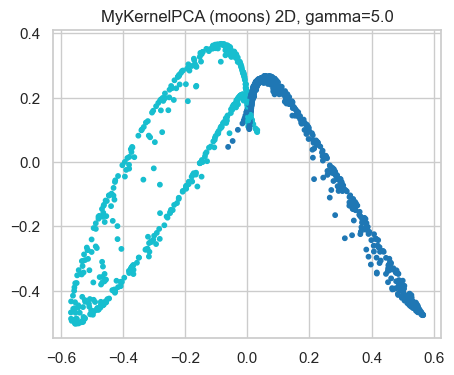

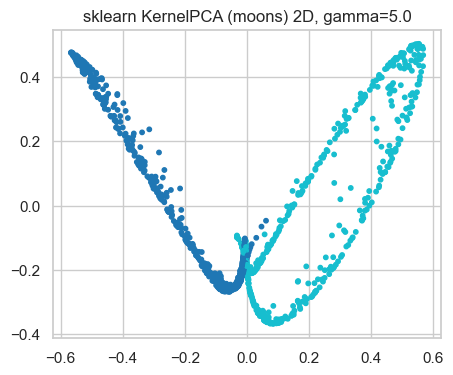

In [11]:
from sklearn.decomposition import KernelPCA

def rbf_kernel_matrix(X, Y=None, gamma=1.0):
    """
    Вычисляет RBF-ядро (Gaussian kernel) между матрицами X и Y.
    
    Параметры:
        X: np.ndarray, shape (n_samples_X, n_features)
        Y: np.ndarray, shape (n_samples_Y, n_features) или None → тогда Y = X
        gamma: float > 0, ширина ядра (gamma = 1/(2*sigma^2))
    
    Возвращает:
        K: np.ndarray, shape (n_samples_X, n_samples_Y)
    """
    if Y is None:
        Y = X
    X_norm_sq = np.sum(X**2, axis=1, keepdims=True)
    Y_norm_sq = np.sum(Y**2, axis=1, keepdims=True).T
    # ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x·y
    distances_sq = X_norm_sq + Y_norm_sq - 2 * X @ Y.T
    # избегаем отрицательных значений из-за ошибок округления
    distances_sq = np.maximum(distances_sq, 0)
    K = np.exp(-gamma * distances_sq)
    return K


class MyKernelPCA:
    def __init__(self, n_components=2, gamma=1.0, copy=True):
        self.n_components = n_components
        self.gamma = gamma
        self.copy = copy
        self.X_train_ = None
        self.alphas_ = None
        self.lambdas_ = None
        self.K_train_ = None
        self._centering_matrix = None

    def _center_kernel_matrix(self, K, store_centering_matrix=False):
        N = K.shape[0]
        one_n = np.ones((N, N)) / N
        K_centered = K - one_n @ K - K @ one_n + one_n @ K @ one_n
        if store_centering_matrix:
            self._centering_matrix = one_n
        return K_centered

    def fit(self, X):
        """
        Обучает Kernel PCA на данных X.
        """
        if self.copy:
            X = X.copy()
        self.X_train_ = X
        N = X.shape[0]

        # вычисляем ядерную матрицу
        K = rbf_kernel_matrix(X, gamma=self.gamma)
        self.K_train_ = K

        # центрируем ядерную матрицу и кэшируем 1_N
        K_centered = self._center_kernel_matrix(K, store_centering_matrix=True)

        # решаем задачу на собственные значения
        eigenvalues, eigenvectors = np.linalg.eigh(K_centered)

        # Сортируем по убыванию
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Отбрасываем неположительные собственные значения
        # Используем небольшой порог для численной устойчивости
        tol = 1e-12
        positive_mask = eigenvalues > tol
        if not np.any(positive_mask):
            raise ValueError("Все собственные значения ≤ 0. Попробуйте уменьшить gamma, отмасштабировать данные или проверить вход.")

        eigenvalues = eigenvalues[positive_mask]
        eigenvectors = eigenvectors[:, positive_mask]

        n_comp = min(self.n_components, len(eigenvalues))
        self.lambdas_ = eigenvalues[:n_comp]
        eigenvectors_selected = eigenvectors[:, :n_comp]

        # Нормируем собственные векторы
        # Делаем по столбцам
        self.alphas_ = eigenvectors_selected / np.sqrt(self.lambdas_)

        return self

    def transform(self, X):
        """Проецирует X в пространство главных компонент."""
        if self.X_train_ is None or self.alphas_ is None:
            raise ValueError("Метод fit не вызван.")

        if self.copy:
            X = X.copy()

        M = X.shape[0]
        N = self.X_train_.shape[0]

        # Ядро между тестовыми и обучающими данными
        K_test = rbf_kernel_matrix(X, self.X_train_, gamma=self.gamma)
        K_train = self.K_train_

        # Центрирование K_test
        one_M = np.ones((M, N)) / N
        one_N = self._centering_matrix

        K_test_centered = (
            K_test
            - one_M @ K_train
            - K_test @ one_N
            + one_M @ K_train @ one_N
        )

        # Проекция
        X_transformed = K_test_centered @ self.alphas_
        return X_transformed

mkp = MyKernelPCA(n_components=2, gamma=5.0).fit(X_moons_s)
Zk = mkp.transform(X_moons_s)
plt.figure(figsize=(5,4))
plt.scatter(Zk[:,0], Zk[:,1], c=y_moons, cmap='tab10', s=10)
plt.title('MyKernelPCA (moons) 2D, gamma=5.0')
plt.show()

sk_kp = KernelPCA(n_components=2, kernel='rbf', gamma=5.0, random_state=42)
Zk_sk = sk_kp.fit_transform(X_moons_s)
plt.figure(figsize=(5,4))
plt.scatter(Zk_sk[:,0], Zk_sk[:,1], c=y_moons, cmap='tab10', s=10)
plt.title('sklearn KernelPCA (moons) 2D, gamma=5.0')
plt.show()

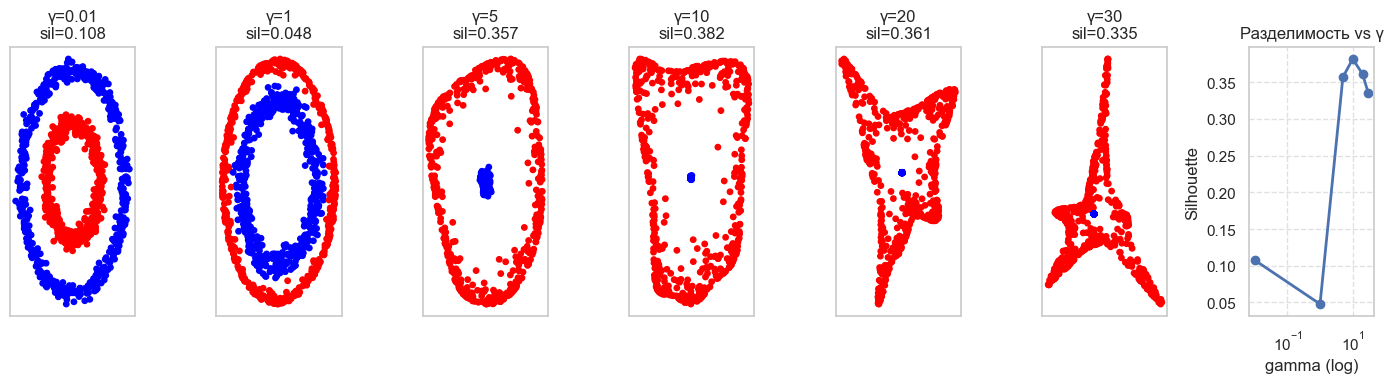

Лучший gamma: 10 → silhouette = 0.3816


In [12]:
gammas = [0.01, 1, 5, 10, 20, 30]
silhouettes = []

plt.figure(figsize=(14, 4))

for i, gamma in enumerate(gammas):
    # Обучение и проекция в 2D
    kpca = MyKernelPCA(n_components=2, gamma=gamma).fit(X_circles_s)
    X_kpca = kpca.transform(X_circles_s)
    
    # Silhouette score
    sil = silhouette_score(X_kpca, y_circles)
    silhouettes.append(sil)
    
    # Визуализация
    plt.subplot(1, len(gammas)+1, i+1)
    plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_circles, cmap='bwr', s=15)
    plt.title(f'γ={gamma}\nsil={sil:.3f}')
    plt.xticks([]); plt.yticks([])

# График silhouette vs gamma
plt.subplot(1, len(gammas)+1, len(gammas)+1)
plt.plot(gammas, silhouettes, 'bo-', linewidth=2, markersize=6)
plt.xscale('log')
plt.xlabel('gamma (log)')
plt.ylabel('Silhouette')
plt.title('Разделимость vs γ')
plt.grid(True, ls='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Вывод лучшего gamma
best_idx = np.argmax(silhouettes)
print(f"Лучший gamma: {gammas[best_idx]} → silhouette = {silhouettes[best_idx]:.4f}")

## 5. Упрощённая реализация t-SNE
Основные шаги:
1) В высокомерном пространстве для каждой точки i подбирается \\(\\sigma_i\\) так, чтобы энтропия распределения соседей соответствовала заданной `perplexity`.
2) Вычисляются симметричные вероятности \\(P_{ij}\\).
3) В низкой размерности оптимизируется \\(Y\\) минимизацией Kullback–Leibler расхождения между P и Q (где Q — t-распределение).
    
В качестве учебной реализации достаточно:
- Реализовать поиск \\(\\sigma_i\\) бинарным поиском по заданной perplexity.
- Оптимизировать Y градиентным спуском с моментумом.
- Показать влияние `perplexity` и `learning_rate` на Iris и на `digits` (подмножество для скорости, например 2000 точек).

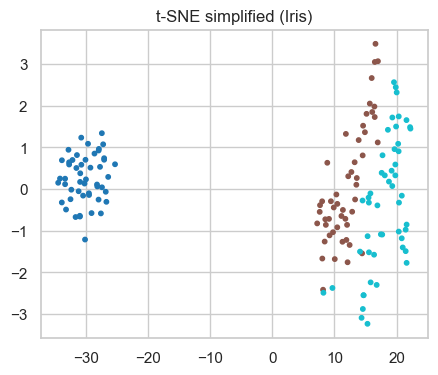

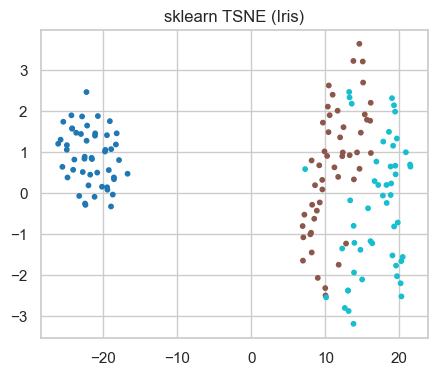

Corr X: 0.9987225789294126
Corr Y: 0.6496052442055981


In [13]:
from sklearn.manifold import TSNE as SKTSNE

def Hbeta(D, beta):
    """
    Вычисляет симметричные вероятности P[j|i] и энтропию H(P_i)
    D: вектор расстояний от точки i до остальных (без диагонали)
    beta = 1 / (2 * sigma_i^2)
    Возвращает (H, P), где P = exp(-beta * D) нормализовано
    """
    P = np.exp(-beta * D)
    sum_P = np.sum(P)
    if sum_P == 0:
        # Избегаем деления на ноль при переполнении
        H = 0.0
        P = np.zeros_like(P)
    else:
        P = P / sum_P
        H = np.log(sum_P) + beta * np.sum(D * P)
    return H, P

def binary_search_perplexity(D, perplexity=30.0, tol=1e-5, max_iter=50):
    """
    Находит beta (=> sigma) для i-й точки так, чтобы perplexity(P_i) ≈ заданной.
    D: расстояния от точки i до других точек (1D массив, shape=(n-1,))
    Возвращает вектор P_i (нормированные вероятности), shape=(n-1,)
    """
    target_H = np.log(perplexity)
    beta_min = -np.inf
    beta_max = np.inf
    beta = 1.0

    H, P = Hbeta(D, beta)
    H_diff = H - target_H

    for _ in range(max_iter):
        if np.abs(H_diff) < tol:
            break
        if H_diff > 0:
            beta_min = beta
            if beta_max == np.inf:
                beta *= 2.0
            else:
                beta = (beta + beta_max) / 2.0
        else:
            beta_max = beta
            if beta_min == -np.inf:
                beta /= 2.0
            else:
                beta = (beta + beta_min) / 2.0
        H, P = Hbeta(D, beta)
        H_diff = H - target_H

    return P

def tsne_simplified(X, n_components=2, perplexity=30.0, learning_rate=200.0, n_iter=1000, seed=42):
    """
    Упрощённая реализация t-SNE
    """
    np.random.seed(seed)
    n_samples = X.shape[0]

    # Попарные квадраты расстояний
    sum_X = np.sum(np.square(X), axis=1)
    D_sq = sum_X[:, None] + sum_X[None, :] - 2 * np.dot(X, X.T)
    np.fill_diagonal(D_sq, 0.0)
    D_sq = np.maximum(D_sq, 0.0)

    # Вычисление P_i для каждой точки и симметризация
    P = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        idx = np.arange(n_samples) != i
        D_i = D_sq[i, idx]
        P_i = binary_search_perplexity(D_i, perplexity=perplexity)
        P[i, idx] = P_i

    # Симметризуем
    P = (P + P.T) / (2.0 * n_samples)
    P = np.maximum(P, 1e-12)  # для стабильности

    P_exag = P * 8.0

    # Инициализация Y
    Y = np.random.normal(loc=0.0, scale=1e-4, size=(n_samples, n_components))
    Y_momentum = np.zeros_like(Y)

    for it in range(n_iter):
        # Выбираем P (с exaggeration или без)
        if it < 250:
            P_use = P_exag
            momentum = 0.5
        else:
            P_use = P
            momentum = 0.8

        # Вычисление Q
        sum_Y = np.sum(np.square(Y), axis=1)
        num = 1.0 / (1.0 + sum_Y[:, None] + sum_Y[None, :] - 2 * np.dot(Y, Y.T))
        np.fill_diagonal(num, 0.0)
        Q = num / np.sum(num)
        Q = np.maximum(Q, 1e-12)

        # 4. Градиент
        PQ = P_use - Q 
        grad = np.zeros_like(Y)
        for i in range(n_samples):
            diff = Y[i] - Y
            grad[i] = 4.0 * np.sum((PQ[i, :, None] * diff) * num[i, :, None], axis=0)

        # 5. Обновление с momentum
        Y_momentum = momentum * Y_momentum - learning_rate * grad
        Y += Y_momentum

    return Y

# Демонстрация на Iris
Z_tsne = tsne_simplified(
    X_iris_s,
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    seed=42
)
plt.figure(figsize=(5,4))
plt.scatter(Z_tsne[:,0], Z_tsne[:,1], c=y_iris, cmap='tab10', s=10)
plt.title('t-SNE simplified (Iris)')
plt.show()

# Сравнение с sklearn TSNE (для справки)
Z_tsne_sk = SKTSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init='random',
    max_iter=1000,
    random_state=42
).fit_transform(X_iris_s)
plt.figure(figsize=(5,4))
plt.scatter(Z_tsne_sk[:,0], Z_tsne_sk[:,1], c=y_iris, cmap='tab10', s=10)
plt.title('sklearn TSNE (Iris)')
plt.show()

print("Corr X:", np.corrcoef(Z_tsne[:,0], Z_tsne_sk[:,0])[0,1])
print("Corr Y:", np.corrcoef(Z_tsne[:,1], Z_tsne_sk[:,1])[0,1])

C:\Users\Никита\AppData\Local\Temp\ipykernel_10276\1384476892.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


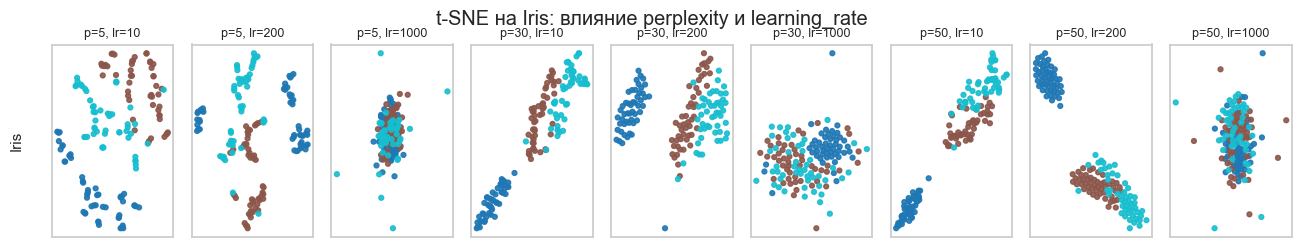

In [14]:
perplexities = [5, 30, 50]
learning_rates = [10, 200, 1000]

fig, axes = plt.subplots(1, 9, figsize=(16, 2.5), gridspec_kw={'hspace': 0.25, 'wspace': 0.15})

for j, (perp, lr) in enumerate([(p, l) for p in perplexities for l in learning_rates]):
    Z = tsne_simplified(X_iris_s, perplexity=perp, learning_rate=lr, n_iter=500, seed=42)
    ax = axes[j]
    ax.scatter(Z[:, 0], Z[:, 1], c=y_iris, s=12, cmap='tab10', alpha=0.9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'p={perp}, lr={lr}', fontsize=9)

axes[0].set_ylabel('Iris', fontsize=11, rotation=90, labelpad=20)
plt.suptitle('t-SNE на Iris: влияние perplexity и learning_rate', y=1.02)
plt.tight_layout()
plt.show()

## 7. Выводы и рекомендации
Напишите выводы:
- Как выбор `eps/min_samples` влияет на DBSCAN в данных с различной формой кластеров.

Выбор параметров eps и min_samples в DBSCAN критически влияет на качество кластеризации, особенно при разнообразных формах и плотностях кластеров: малое значение eps может привести к фрагментации плотных кластеров или избытку шумовых точек, тогда как слишком большое eps объединит разнородные структуры; высокое min_samples повышает устойчивость к выбросам, но может «размыть» компактные кластеры, тогда как низкое значение делает алгоритм чувствительным к шуму — оптимальный баланс достигается при анализе k-расстояний и учёте локальной плотности.

- Когда `diag` ковариация у GMM предпочтительнее `full` (скорость/устойчивость).

Ковариационная структура diag в GMM предпочтительна перед full, когда важны вычислительная эффективность и численная устойчивость: diag предполагает независимость признаков (нулевые внедиагональные элементы), что резко снижает число параметров, ускоряя обучение и уменьшая риск переобучения при малом объёме данных или высокой размерности; full даёт гибкость в моделировании корреляций, но требует больше данных, времени и регуляризации для стабильности — diag часто оказывается практичным компромиссом, особенно при предварительном отборе признаков или в иерархических ансамблях.

- Чем полезен Kernel PCA по сравнению с линейным PCA на нелинейно разделимых данных.

Kernel PCA полезен на нелинейно разделимых данных, поскольку с помощью ядерной функции (например, RBF) неявно отображает исходные признаки в более высокомерное пространство, где структуры могут стать линейно разделимыми, что позволяет извлечь сложные нелинейные компоненты, недоступные линейному PCA — например, при наличии спиралевидных или концентрических кластеров линейный PCA сохранит мало объяснимой дисперсии по первым компонентам, тогда как Kernel PCA может успешно их развернуть, улучшая как визуализацию, так и последующую классификацию.

- Как выбирать `perplexity` и `learning_rate` для t-SNE, и когда t-SNE предпочтительнее Kernel PCA.

Параметр perplexity в t-SNE отражает эффективное количество соседей и должен быть выбран в диапазоне ~5–50 (чаще 30–50 для умеренных объёмов данных), чтобы балансировать локальную и глобальную структуру; слишком малая перплексия усиливает шум, слишком большая — сглаживает детали. learning_rate (обычно 10–1000) регулирует шаг градиентного спуска: низкие значения вызывают застревание в локальных минимумах, высокие — нестабильность.

t-SNE предпочтительнее Kernel PCA, когда цель — качественная 2D-визуализация локальных структур и кластеров (особенно при интерпретации человеком), тогда как Kernel PCA лучше подходит для последующего обучения моделей или сохранения глобальных отношений при умеренной нелинейности.